In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('demo.csv')
display(df.head())

,Date,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity
0,2025/01/01,45.0,Sunny,Dry,Bike,Day,1.0,Minor
1,2025-01-02,60.0,Rainy,W,Car,Night,0.0,Serious
2,2025-01-03,80.0,Foggy,Wet,Truck,Night,NaN,Fatal
3,2025-01-04,50.0,Sunny,Dry,Car,Day,1.0,Minor
4,2025-01-05,70.0,Rainy,W,Bike,Night,0.0,Serious


In [2]:
print(df.head())
print(df.info())
print(df.describe())

         Date  Speed Weather Road_Condition Vehicle_Type   Time  \
0  2025/01/01   45.0   Sunny            Dry         Bike    Day   
1  2025-01-02   60.0   Rainy              W          Car  Night   
2  2025-01-03   80.0   Foggy            Wet        Truck  Night   
3  2025-01-04   50.0   Sunny            Dry          Car    Day   
4  2025-01-05   70.0   Rainy              W         Bike  Night   

   Seatbelt/Helmet Severity  
0              1.0    Minor  
1              0.0  Serious  
2              NaN    Fatal  
3              1.0    Minor  
4              0.0  Serious  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             48 non-null     object 
 1   Speed            44 non-null     float64
 2   Weather          47 non-null     object 
 3   Road_Condition   48 non-null     object 
 4   Vehicle_Type     45 non-null     o

In [3]:
df.columns = df.columns.str.strip()


In [4]:
df['Date'] = pd.to_datetime(df['Date'],format='mixed',dayfirst=True,errors='coerce' )
#Convert to desired format (DD/MM/YYYY)
df['Date'] = df['Date'].dt.strftime("%d/%m/%Y")
df['Date'] = df['Date'].fillna(df['Date'].mode()[0])

In [5]:
df.head()

,Date,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity
0,01/01/2025,45.0,Sunny,Dry,Bike,Day,1.0,Minor
1,02/01/2025,60.0,Rainy,W,Car,Night,0.0,Serious
2,03/01/2025,80.0,Foggy,Wet,Truck,Night,NaN,Fatal
3,04/01/2025,50.0,Sunny,Dry,Car,Day,1.0,Minor
4,05/01/2025,70.0,Rainy,W,Bike,Night,0.0,Serious


In [6]:
df['Road_Condition'] = df['Road_Condition'].replace({
'W': 'Wet',
'D': 'Dry'
})

In [7]:
print(df.isnull().sum())

Date                0
Speed               6
Weather             3
Road_Condition      2
Vehicle_Type        5
Time                6
Seatbelt/Helmet    12
Severity            0
dtype: int64


In [8]:
df['Speed'].fillna(df['Speed'].mean(), inplace=True)

In [9]:
for col in ['Weather', 'Road_Condition', 'Vehicle_Type', 'Time']:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [10]:
df['Seatbelt/Helmet'].fillna(0, inplace=True)

In [11]:
df.dropna(subset=['Severity'], inplace=True)


In [12]:
df.drop_duplicates(inplace=True)


In [13]:
df.isna().sum()


Date               0
Speed              0
Weather            0
Road_Condition     0
Vehicle_Type       0
Time               0
Seatbelt/Helmet    0
Severity           0
dtype: int64

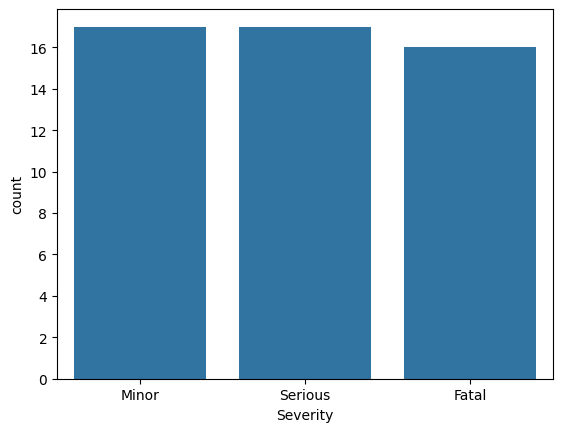

In [14]:
sns.countplot(x='Severity', data=df)
plt.show()


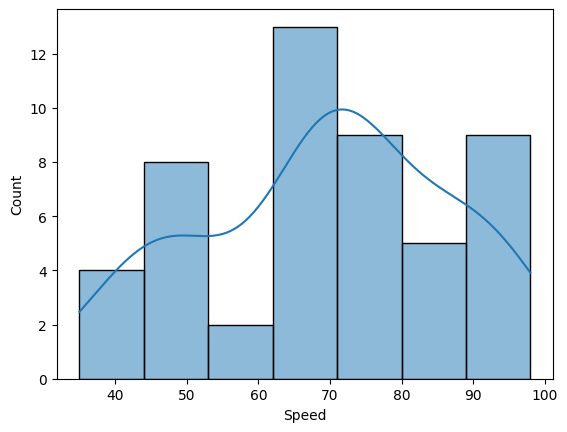

In [15]:
sns.histplot(df['Speed'], kde=True)
plt.show()

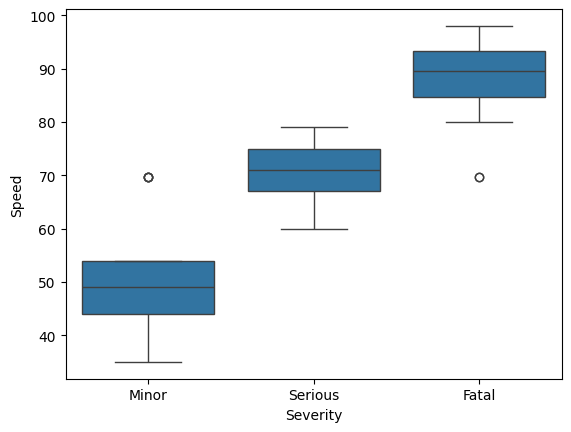

In [16]:
sns.boxplot(x='Severity', y='Speed', data=df)
plt.show()

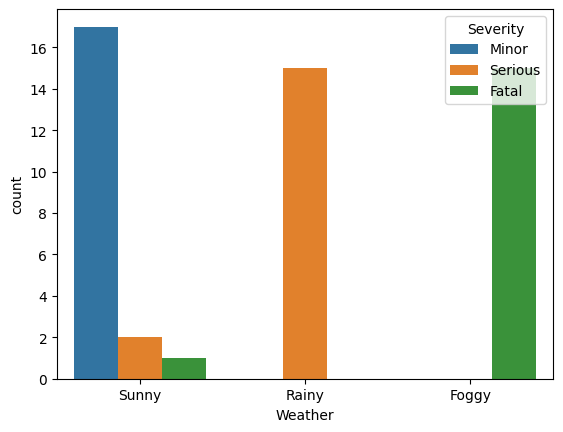

In [17]:
sns.countplot(x='Weather', hue='Severity', data=df)
plt.show()

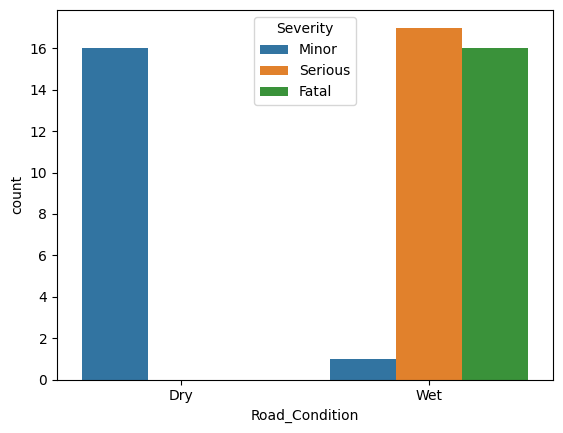

In [18]:
sns.countplot(x='Road_Condition', hue='Severity', data=df)
plt.show()

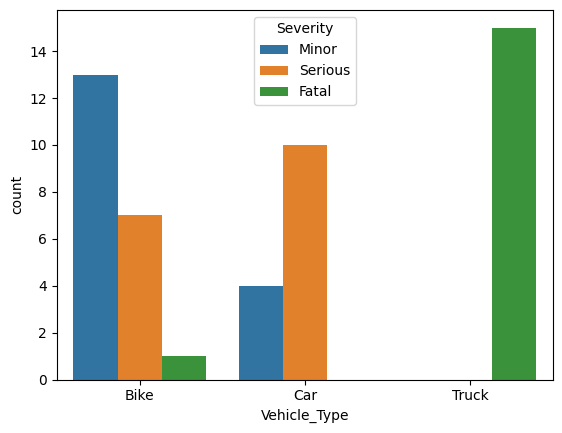

In [19]:
sns.countplot(x='Vehicle_Type', hue='Severity', data=df)
plt.show()


In [20]:
#adding additional Featues and Rows for better accuracy
new_rows = 100
# Create base data
new_data = pd.DataFrame({
'Date': pd.date_range(start='2025-03-01', periods=new_rows, freq='D'),
'Speed': np.random.randint(30, 100, new_rows),
'Weather': np.random.choice(['Sunny', 'Rainy', 'Foggy'], new_rows),
'Road_Condition': np.random.choice(['Dry', 'Wet'], new_rows),
'Vehicle_Type': np.random.choice(['Bike', 'Car', 'Truck'], new_rows),
'Time': np.random.choice(['Day', 'Night'], new_rows),
'Seatbelt/Helmet': np.random.choice([0,1], new_rows),
'Severity': np.random.choice(['Minor', 'Serious', 'Fatal'], new_rows),
'Is_Night': np.random.choice([0,1], new_rows),
'Speed_Category': np.random.choice(['Low', 'Medium', 'High'], new_rows),
'Safety': np.random.choice(['Safe', 'Unsafe'], new_rows)
})

In [21]:

new_data['Is_Night'] = new_data['Time'].apply(lambda x: 1 if x == 'Night' else 0)
df['Is_Night'] = df['Time'].apply(lambda x: 1 if x == 'Night' else 0)

In [22]:
def speed_category(speed):
    if speed < 50:
        return "Low"
    elif speed < 80:
        return "Medium"
    else:
        return "High"
new_data['Speed_Category'] = new_data['Speed'].apply(speed_category)
df['Speed_Category'] = df['Speed'].apply(speed_category)

In [23]:
new_data['Safety'] = new_data['Seatbelt/Helmet'].apply(
lambda x: "Safe" if x == 1 else "Unsafe"
)
df['Safety'] = df['Seatbelt/Helmet'].apply(
lambda x: "Safe" if x == 1 else "Unsafe"
)

In [25]:
def assign_severity(row):
    if row['Speed'] > 85 and row['Road_Condition'] == 'Wet':
        return 'Fatal'
    elif row['Speed'] > 65:
        return 'Serious'
    else:
        return 'Minor'
new_data['Severity'] = new_data.apply(assign_severity, axis=1)
df['Severity'] = df.apply(assign_severity, axis=1)

In [26]:
df = pd.concat([df, new_data], ignore_index=True)


In [27]:
df['Date'] = pd.to_datetime(df['Date'],format='mixed',dayfirst=True,errors='coerce' )
#Convert to desired format (DD/MM/YYYY)
df['Date'] = df['Date'].dt.strftime("%d/%m/%Y")
df['Date'] = df['Date'].fillna(df['Date'].mode()[0])

In [28]:
df.isna().sum()


Date               0
Speed              0
Weather            0
Road_Condition     0
Vehicle_Type       0
Time               0
Seatbelt/Helmet    0
Severity           0
Is_Night           0
Speed_Category     0
Safety             0
dtype: int64

In [29]:
df.to_csv("improved_accident_data.csv", index=False)

In [30]:
df = df.drop('Date', axis=1)

In [31]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in ['Weather', 'Road_Condition', 'Vehicle_Type', 'Time', 'Severity', 'Speed_Category', 'Safety']:
    df[col] = df[col].astype(str) # Ensure all values are strings before encoding
    df[col] = encoder.fit_transform(df[col])
display(df.head())


,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity,Is_Night,Speed_Category,Safety
0,45.0,2,0,0,0,1.0,1,0,1,0
1,60.0,1,1,1,1,0.0,1,1,2,1
2,80.0,0,1,2,1,0.0,2,1,0,1
3,50.0,2,0,1,0,1.0,1,0,2,0
4,70.0,1,1,0,1,0.0,2,1,2,1


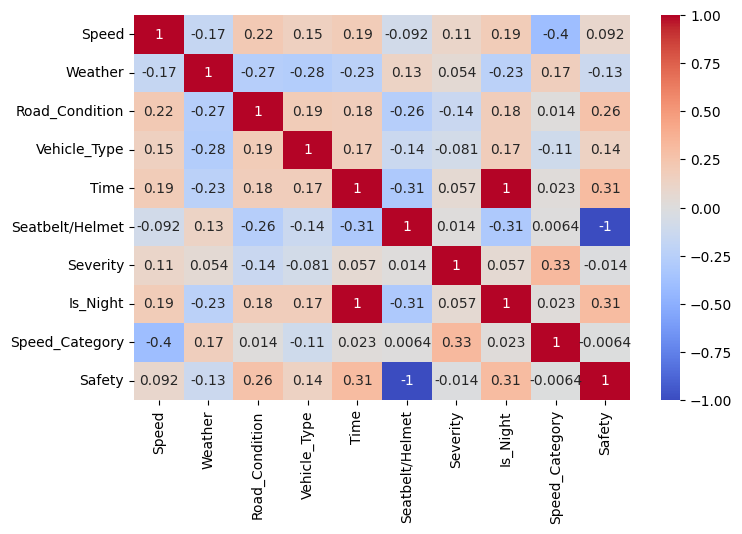

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['Speed', 'Seatbelt/Helmet']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [34]:
df.head()

,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity,Is_Night,Speed_Category,Safety
0,-0.989747,2,0,0,0,1.191367,1,0,1,0
1,-0.244875,1,1,1,1,-0.839372,1,1,2,1
2,0.748288,0,1,2,1,-0.839372,2,1,0,1
3,-0.741456,2,0,1,0,1.191367,1,0,2,0
4,0.251706,1,1,0,1,-0.839372,2,1,2,1
